In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from manify.manifolds import ProductManifold
from manify.curvature_estimation.delta_hyperbolicity import delta_hyperbolicity, sampled_delta_hyperbolicity
import torch
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Delta Hyperbolicity Max')

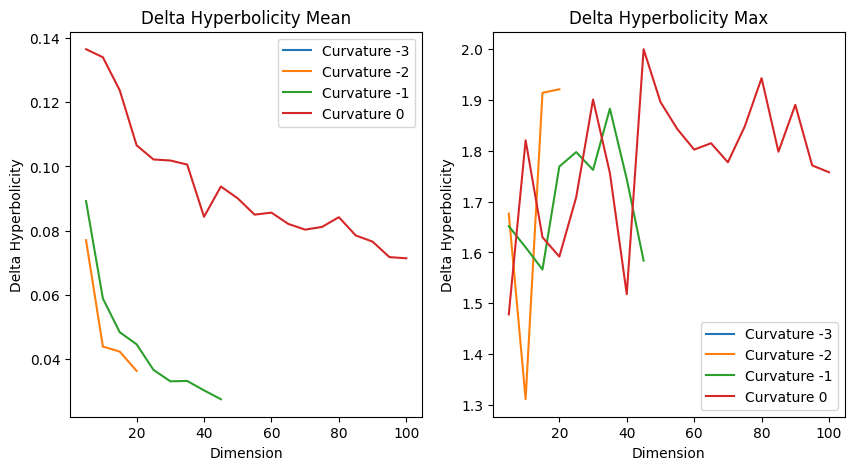

In [14]:
# Curvatures and Dimension in hyperbolic distance metrics

N_SAMPLES = 100

dims = np.linspace(5,100,20, dtype=int).tolist()
curvatures = [-3, -2, -1, 0]

delta_means = [[] for _ in curvatures]
delta_maxes = [[] for _ in curvatures]

for i,k in enumerate(curvatures):
    for dim in dims:
        pm = ProductManifold(signature=[(k, dim)])
        X, _ = pm.sample(z_mean=torch.stack([pm.mu0] * N_SAMPLES))
        dists = pm.dist(X, X)
        delta_means[i].append(delta_hyperbolicity(dists).mean().item())
        delta_maxes[i].append(delta_hyperbolicity(dists).max().item())

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for i,k in enumerate(curvatures):
    axs[0].plot(dims, delta_means[i], label=f'Curvature {k}')
    axs[1].plot(dims, delta_maxes[i], label=f'Curvature {k}')

axs[0].legend()
axs[0].set_xlabel('Dimension')
axs[0].set_ylabel('Delta Hyperbolicity')
axs[0].set_title('Delta Hyperbolicity Mean')
axs[1].legend()
axs[1].set_xlabel('Dimension')
axs[1].set_ylabel('Delta Hyperbolicity')
axs[1].set_title('Delta Hyperbolicity Max')


In [9]:
delta_means[0]

[0.0984811931848526,
 0.05335831269621849,
 0.041888441890478134,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]